In [1]:
#ImportingLibraries needed for the analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score



In [2]:
#Loading the data
#File path variables

Local_path = 'C:/Users/beatr/OneDrive/Desktop/WGU/D212/Data/'

InputFilePath = Local_path + 'churn_clean.csv'
OutputfilePath =  Local_path + 'churn_cleaned_df.csv'
Scaledfilepath = Local_path + 'scaled_df.csv'

Churn_df = pd.read_csv(InputFilePath)

In [3]:
#Initial data exploration (Understanding the data)
pd.set_option('display.max_columns', None)
Churn_df.head()


,CaseOrder,Customer_id,Interaction,UID,City,State,County,Zip,Lat,Lng,Population,Area,TimeZone,Job,Children,Age,Income,Marital,Gender,Churn,Outage_sec_perweek,Email,Contacts,Yearly_equip_failure,Techie,Contract,Port_modem,Tablet,InternetService,Phone,Multiple,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,PaymentMethod,Tenure,MonthlyCharge,Bandwidth_GB_Year,Item1,Item2,Item3,Item4,Item5,Item6,Item7,Item8
0,1,K409198,aa90260b-4141-4a24-8e36-b04ce1f4f77b,e885b299883d4f9fb18e39c75155d990,Point Baker,AK,Prince of Wales-Hyder,99927,56.25100,-133.37571,38,Urban,America/Sitka,Environmental health practitioner,0,68,28561.99,Widowed,Male,No,7.978323,10,0,1,No,One year,Yes,Yes,Fiber Optic,Yes,No,Yes,Yes,No,No,No,Yes,Yes,Credit Card (automatic),6.795513,172.455519,904.536110,5,5,5,3,4,4,3,4
1,2,S120509,fb76459f-c047-4a9d-8af9-e0f7d4ac2524,f2de8bef964785f41a2959829830fb8a,West Branch,MI,Ogemaw,48661,44.32893,-84.24080,10446,Urban,America/Detroit,"Programmer, multimedia",1,27,21704.77,Married,Female,Yes,11.699080,12,0,1,Yes,Month-to-month,No,Yes,Fiber Optic,Yes,Yes,Yes,No,No,No,Yes,Yes,Yes,Bank Transfer(automatic),1.156681,242.632554,800.982766,3,4,3,3,4,3,4,4
2,3,K191035,344d114c-3736-4be5-98f7-c72c281e2d35,f1784cfa9f6d92ae816197eb175d3c71,Yamhill,OR,Yamhill,97148,45.35589,-123.24657,3735,Urban,America/Los_Angeles,Chief Financial Officer,4,50,9609.57,Widowed,Female,No,10.752800,9,0,1,Yes,Two Year,Yes,No,DSL,Yes,Yes,No,No,No,No,No,Yes,Yes,Credit Card (automatic),15.754144,159.947583,2054.706961,4,4,2,4,4,3,3,3
3,4,D90850,abfa2b40-2d43-4994-b15a-989b8c79e311,dc8a365077241bb5cd5ccd305136b05e,Del Mar,CA,San Diego,92014,32.96687,-117.24798,13863,Suburban,America/Los_Angeles,Solicitor,1,48,18925.23,Married,Male,No,14.913540,15,2,0,Yes,Two Year,No,No,DSL,Yes,No,Yes,No,No,No,Yes,No,Yes,Mailed Check,17.087227,119.956840,2164.579412,4,4,4,2,5,4,3,3
4,5,K662701,68a861fd-0d20-4e51-a587-8a90407ee574,aabb64a116e83fdc4befc1fbab1663f9,Needville,TX,Fort Bend,77461,29.38012,-95.80673,11352,Suburban,America/Chicago,Medical illustrator,0,83,40074.19,Separated,Male,Yes,8.147417,16,2,1,No,Month-to-month,Yes,No,Fiber Optic,No,No,No,No,No,Yes,Yes,No,No,Mailed Check,1.670972,149.948316,271.493436,4,4,4,3,4,4,4,5


In [4]:
Churn_df.shape

(10000, 50)

In [5]:
Churn_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 50 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   CaseOrder             10000 non-null  int64  
 1   Customer_id           10000 non-null  object 
 2   Interaction           10000 non-null  object 
 3   UID                   10000 non-null  object 
 4   City                  10000 non-null  object 
 5   State                 10000 non-null  object 
 6   County                10000 non-null  object 
 7   Zip                   10000 non-null  int64  
 8   Lat                   10000 non-null  float64
 9   Lng                   10000 non-null  float64
 10  Population            10000 non-null  int64  
 11  Area                  10000 non-null  object 
 12  TimeZone              10000 non-null  object 
 13  Job                   10000 non-null  object 
 14  Children              10000 non-null  int64  
 15  Age                 

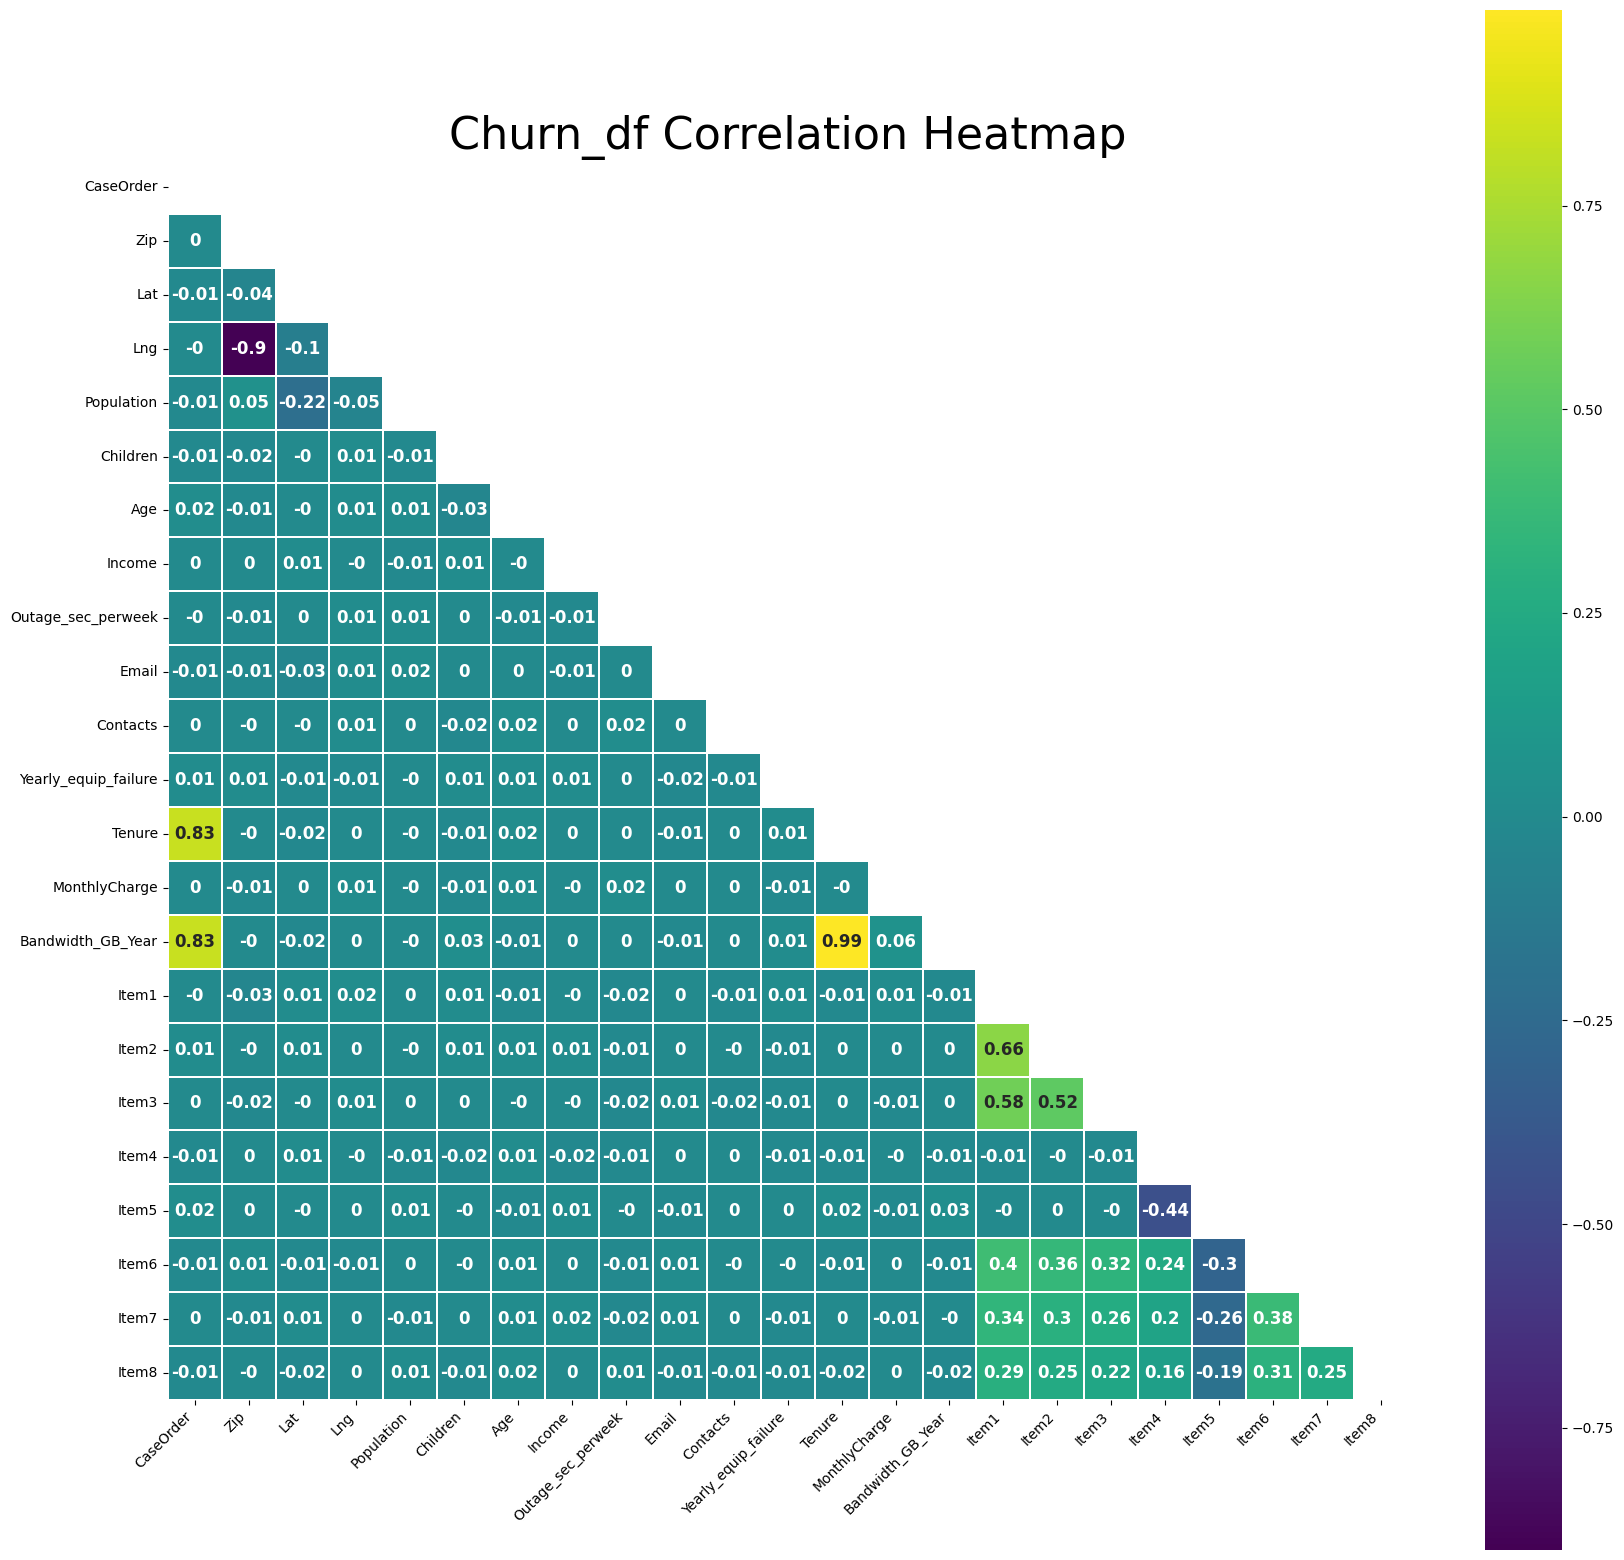

In [6]:
#Analysing the Correlation  /Relationship analysis
Continous_columns = Churn_df.select_dtypes(include=['float64', 'int64']).columns.tolist()
Cor_data = Churn_df[Continous_columns]

def Generate_heatmap_graph(corr, chart_title, mask_uppertri=False):
    """ Based on features, generate a correlation matrix """
    mask = np.zeros_like(corr, dtype=bool)
    mask[np.triu_indices_from(mask)] = mask_uppertri
    fig, ax = plt.subplots(figsize=(20, 20))
    sns.heatmap(corr,
                mask=mask,
                square=True,
                annot=True,
                annot_kws={'size': 12, 'rotation': 0, 'weight': 'bold'},
                cmap=plt.get_cmap('viridis'),
                linewidths=.1,
                ax=ax)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # Rotate x-axis labels
    plt.title(chart_title, fontsize=32)
    plt.show()
var_corr = round(Cor_data.corr(), 2)
Generate_heatmap_graph(var_corr, chart_title='Churn_df Correlation Heatmap', mask_uppertri=True)

In [7]:
# Select the features that have continous data  for clustering
features_df = Churn_df[['Tenure', 'MonthlyCharge', 'Bandwidth_GB_Year']]

In [8]:
#Checking for Nulls and missing data
print(features_df[features_df[features_df .columns[features_df .isna().any()]].columns].info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Empty DataFrame
None


In [9]:
#Dropping any missing values 
features_df = features_df.dropna()

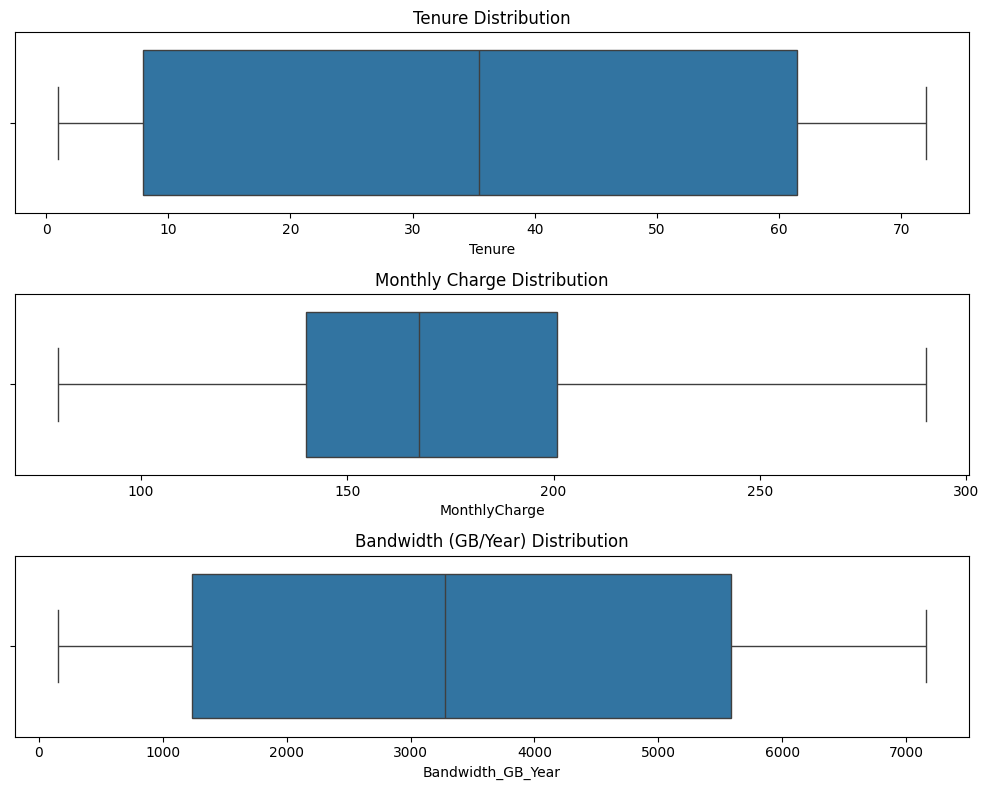

In [10]:
#Checking for Outliers in the dataset
# Set up the figure and axes
fig, axes = plt.subplots(3, 1, figsize=(10, 8))  

# Flatten axes array for easy indexing
axes = axes.flatten()

# List of column names and titles
cols = ['Tenure', 'MonthlyCharge', 'Bandwidth_GB_Year']
titles = ['Tenure Distribution', 
          'Monthly Charge Distribution', 'Bandwidth (GB/Year) Distribution']

# Create boxplots
for i, col in enumerate(cols):
    sns.boxplot(data=features_df, x=col, ax=axes[i])
    axes[i].set_title(titles[i])
'Tenure Distribution'
# Adjust layout
plt.tight_layout()
plt.show()

     Tenure  MonthlyCharge  Bandwidth_GB_Year
0 -1.048746      -0.003943          -1.138487
1 -1.262001       1.630326          -1.185876
2 -0.709940      -0.295225          -0.612138
3 -0.659524      -1.226521          -0.561857
4 -1.242551      -0.528086          -1.428184
Scaled data visualization


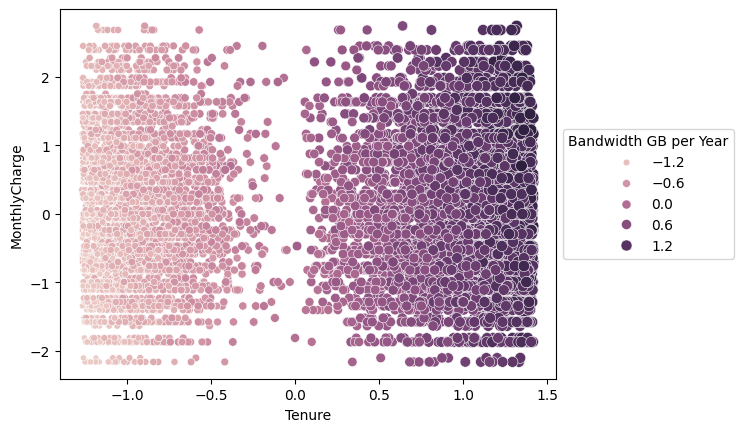

In [11]:
#Data Normaization/scaling the data
#Scaling the data using Standard scaler

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features_df)

#Converting the scaled data to a dataframe
scaled_df= pd.DataFrame(scaled_features ,columns=['Tenure', 'MonthlyCharge', 'Bandwidth_GB_Year'])
print(scaled_df.head())

print("Scaled data visualization")
sns.scatterplot(data=scaled_df, x='Tenure',y='MonthlyCharge' ,hue='Bandwidth_GB_Year', size= 'Bandwidth_GB_Year')
plt.legend( loc='center left',    bbox_to_anchor=(1, 0.5),title='Bandwidth GB per Year'
)

In [12]:
#Extracting cleaned data and scaled data  to CSV file
#Cleaned data
features_df.to_csv(OutputfilePath)

# Scaled data
scaled_df.to_csv(Scaledfilepath)



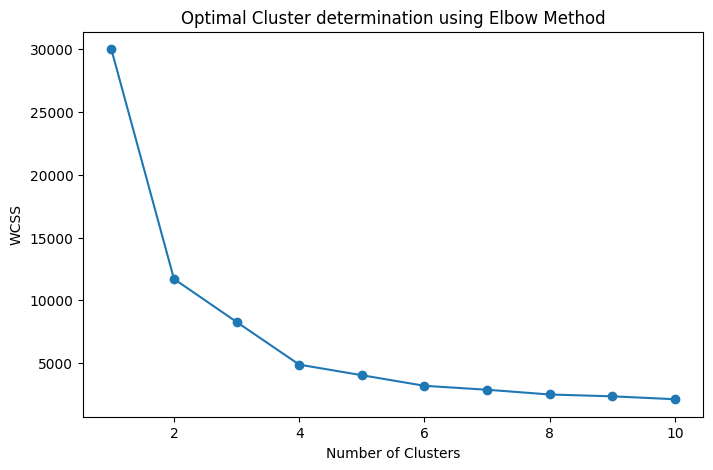

In [13]:
#Determining the optimal number of clusters (k) using an elbow
wcss = []  # Within-Cluster-Sum-of-Squares

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(scaled_df)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Optimal Cluster determination using Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()


In [14]:
#Evaluating the optimal clusters using silhoutte score

#The Silhouette Score is a metric used to evaluate how well clusters are formed in clustering
#algorithms like K-Means. It measures how similar an object is to its own cluster compared to\
#other clusters.

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(scaled_df)
    score = silhouette_score(scaled_df, labels)
    print(f'k={k}, silhouette score={score:.3f}')

k=2, silhouette score=0.564
k=3, silhouette score=0.501
k=4, silhouette score=0.476
k=5, silhouette score=0.433
k=6, silhouette score=0.397
k=7, silhouette score=0.369
k=8, silhouette score=0.370
k=9, silhouette score=0.368
k=10, silhouette score=0.360


In [15]:
#Apply KMeans Clustering
k_optimal = 2 
kmeans_model = KMeans(n_clusters=k_optimal, random_state=42)
Churn_df['Cluster'] = kmeans_model.fit_predict(scaled_df)

In [16]:
# View the cluster centers (centroids) in scaled form
centroids_scaled = kmeans_model.cluster_centers_
centroids_df_scaled = pd.DataFrame(centroids_scaled, columns=scaled_df.columns)
print("Cluster centroids (scaled features):")
print(centroids_df_scaled)

Cluster centroids (scaled features):
     Tenure  MonthlyCharge  Bandwidth_GB_Year
0 -0.960316       0.002542          -0.951889
1  0.960700      -0.002543           0.952270


In [17]:
# Convert the centroids back to the original scale
centroids_original = scaler.inverse_transform(centroids_scaled)
centroids_df_original = pd.DataFrame(centroids_original, columns=scaled_df.columns)
print("\nCluster centroids (original scale):")
print(centroids_df_original)


Cluster centroids (original scale):
      Tenure  MonthlyCharge  Bandwidth_GB_Year
0   9.133764     172.733981        1312.287977
1  59.928772     172.515608        5473.227310


In [18]:
#Summarize Original Data
summary = Churn_df.groupby('Cluster')[['Tenure', 'MonthlyCharge', 'Bandwidth_GB_Year']].mean()
print(summary)

            Tenure  MonthlyCharge  Bandwidth_GB_Year
Cluster                                             
0         9.133764     172.733981        1312.287977
1        59.928772     172.515608        5473.227310


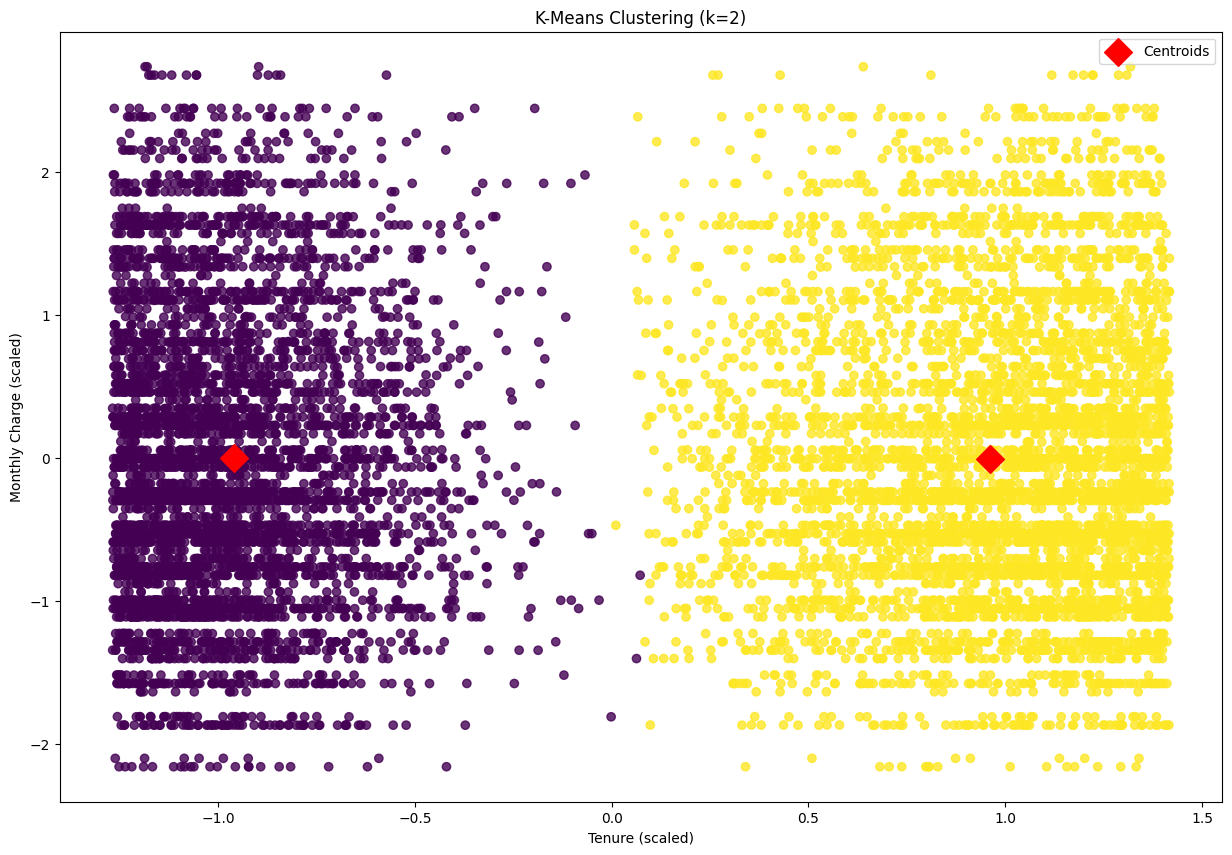

In [19]:
# Visualize the clusters using two features to show where the centroids for k_model are located
plt.figure(figsize=(15, 10))
plt.scatter(scaled_df['Tenure'], 
            scaled_df['MonthlyCharge'],
            c=Churn_df['Cluster'], 
            cmap='viridis', alpha=0.8)
plt.scatter(centroids_scaled[:, 0], 
            centroids_scaled[:, 1], 
            s=200, c='red', 
            marker='D', 
            label='Centroids')
plt.xlabel('Tenure (scaled)')
plt.ylabel('Monthly Charge (scaled)')
plt.title('K-Means Clustering (k=2)')
plt.legend()
#plt.colorbar(label='Cluster')
plt.show()

<Axes: ylabel='Bandwidth_GB_Year'>

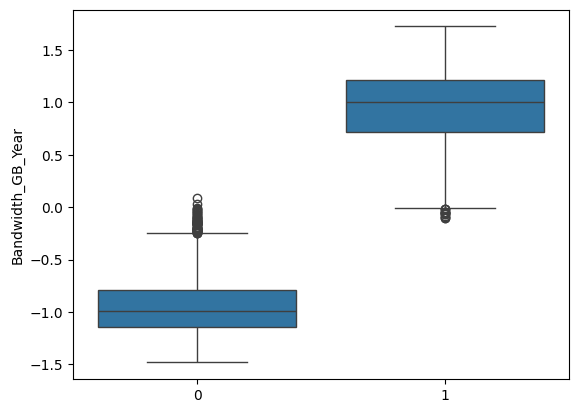

In [20]:
#Displaying the bandwidth for the two kmeans clusters

sns.boxplot(x = kmeans_model.labels_, y = scaled_df['Bandwidth_GB_Year'])

<Axes: ylabel='Tenure'>

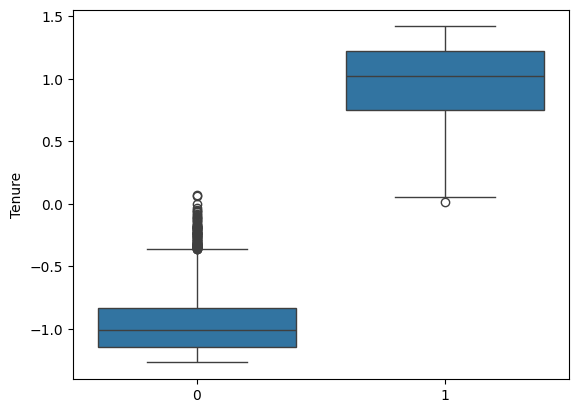

In [21]:
#Displaying the Tenurefor the two kmeans clusters

sns.boxplot(x = kmeans_model.labels_, y = scaled_df['Tenure'])

<Axes: ylabel='MonthlyCharge'>

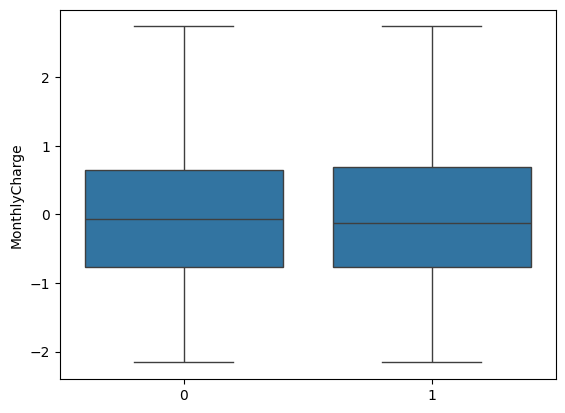

In [22]:
#Displaying the Monthly Charge for the two kmeans clusters

sns.boxplot(x = kmeans_model.labels_, y = scaled_df['MonthlyCharge'])

In [23]:
#  Evaluate cluster quality using Silhouette Score
from sklearn.metrics import silhouette_score

sil_score = silhouette_score(scaled_df, Churn_df['Cluster'])
print(f"\nSilhouette Score for k=2: {sil_score:.3f}")


Silhouette Score for k=2: 0.564


In [24]:
Kmeans_inertia = kmeans_model.inertia_
Kmeans_inertia

11709.63194173196

In [25]:
# Group by cluster and compute averages
cluster_profile = Churn_df.groupby('Cluster')[['Tenure', 'MonthlyCharge', 'Bandwidth_GB_Year']].mean()


# Add count of records per cluster
cluster_profile['Customercount'] = Churn_df['Cluster'].value_counts()
print(cluster_profile)

            Tenure  MonthlyCharge  Bandwidth_GB_Year  Customercount
Cluster                                                            
0         9.133764     172.733981        1312.287977           5001
1        59.928772     172.515608        5473.227310           4999
